# Carros

Esse notebook trabalho com um pequeno dataframe de carros, vamos explorar com AED, encontrar  algumas relações, mas  não vamos sair aleatoriamente. Vamos pensar o que podemos extrair. como base nesses dados:

mpg - Miles/(US) gallon (consumo)

cyl - Numero de cilindros

disp - Cilindradas (cu.in.)

hp - Potencia

drat - relação de transmissão

wt - peso (1000 lbs)

qsec -tempo para percorrer 1/4 de milha

vs - formato do motor (0 = em V, 1 = em linha)

am - Transmissão (0 = automatic, 1 = manual)

gear - Numero de marchar

carb - Numero de carburadores

In [ ]:
# importar os pacotes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para o Seaborn
sns.set_style('whitegrid')

In [ ]:
#link com os dados do mtcars

df = pd.read_csv("https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv")

In [ ]:
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


Para fins didaticos, vamos alterar os nomes e algumas unidades.

In [ ]:

# transformar milhas por galao para litros
df['mpg'] = df['mpg'] * 0.425

# transformar polegadas cubicas para litros
df['disp'] = df['disp'] * 0.0163871

# transformar peso em libras para quilogramas
df['wt'] = df['wt'] * 0.453592


# Substituir nomes das colunas
df = df.rename(columns={
    'mpg': 'consumo',
    'disp': 'cilindradas',
    'wt': 'peso',
    'drap': 'relacao'

})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   model        32 non-null     object 
 1   consumo      32 non-null     float64
 2   cyl          32 non-null     int64  
 3   cilindradas  32 non-null     float64
 4   hp           32 non-null     int64  
 5   drat         32 non-null     float64
 6   peso         32 non-null     float64
 7   qsec         32 non-null     float64
 8   vs           32 non-null     int64  
 9   am           32 non-null     int64  
 10  gear         32 non-null     int64  
 11  carb         32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


In [ ]:
# remover coluna do modelo
df = df.drop('model', axis=1)

In [ ]:

#!pip install skimpy

from skimpy import skim

skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 32     │ │ int64       │ 6     │                                                          │
│ │ Number of columns │ 11     │ │ float64     │ 5     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column         ┃ NA  ┃ NA %  ┃ mean     ┃ sd       ┃ p0       ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ consumo        │   0 │     0 │    8.539 │    2.561 │     4.42 │  6.556 │   8.16 │   9.69 │  14.41 │ ▃█▇▃▁▃ │  │
│ │ cyl            │   0 │     0 │    6.188 │    1.786 │        4 │      4 │      6 │      8 │      8 │ ▆  ▄ █ │  │
│ │ cilindradas    │   0 │     0 │    3.781 │    2.031 │    1.165 │   1.98 │  3.217 │  5.342 │  7.735 │ █▆▂▅▄▃ │  │
│ │ hp             │   0 │     0 │    146.7 │    68.56 │       52 │   96.5 │    123 │    180 │    335 │ █▇▇▃▃▁ │  │
│ │ drat           │   0 │     0 │    3.597 │   0.5347 │     2.76 │   3.08 │  3.695 │   3.92 │   4.93 │ █▄▅█▃▁ │  │
│ │ peso           │   0 │     0 │    1.459 │   0.4438 │   0.6863 │  1.171 │  1.508 │  1.637 │   2.46 │ ▄▅█▆ ▂ │  │
│ │ qsec           │   0 │     0 │    17.85 │    1.787 │     14.5 │  16.89 │  17.71 │   18.9 │   22.9 │ ▄▅█▅▁▁ │  │
│ │ vs             │   0 │     0 │   0.4375 │    0.504 │        0 │      0 │      0 │      1 │      1 │ █    ▆ │  │
│ │ am             │   0 │     0 │   0.4062 │    0.499 │        0 │      0 │      0 │      1 │      1 │ █    ▅ │  │
│ │ gear           │   0 │     0 │    3.688 │   0.7378 │        3 │      3 │      4 │      4 │      5 │ █  ▆ ▃ │  │
│ │ carb           │   0 │     0 │    2.812 │    1.615 │        1 │      2 │      2 │      4 │      8 │  █▁▅   │  │
│ └────────────────┴─────┴───────┴──────────┴──────────┴──────────┴────────┴────────┴────────┴────────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [ ]:
# vamos aplicar testes de normalidade
from scipy import stats

# fazer para todos as colunas
# numero de observações pequenos
for column in df.select_dtypes(include=np.number).columns:
    shapiro_test = stats.shapiro(df[column])
    print(f"Teste de Shapiro-Wilk para '{column}':")
    if shapiro_test.pvalue < 0.05:
        print("Distribuição não normal")
    else:
        print("Distribuição normal")
    print(f"Valor-p: {shapiro_test.pvalue:.4f}")  # Formatar o valor-p para 4 casas decimais
    print("-" * 20)


# Interpretação dos resultados:
# Se o valor-p for menor que 0.05, rejeitamos a hipótese nula de que os dados são normalmente distribuídos.
# Se o valor-p for maior que 0.05, não rejeitamos a hipótese nula.

Teste de Shapiro-Wilk para 'consumo':
Distribuição normal
Valor-p: 0.1229
--------------------
Teste de Shapiro-Wilk para 'cyl':
Distribuição não normal
Valor-p: 0.0000
--------------------
Teste de Shapiro-Wilk para 'cilindradas':
Distribuição não normal
Valor-p: 0.0208
--------------------
Teste de Shapiro-Wilk para 'hp':
Distribuição não normal
Valor-p: 0.0488
--------------------
Teste de Shapiro-Wilk para 'drat':
Distribuição normal
Valor-p: 0.1101
--------------------
Teste de Shapiro-Wilk para 'peso':
Distribuição normal
Valor-p: 0.0927
--------------------
Teste de Shapiro-Wilk para 'qsec':
Distribuição normal
Valor-p: 0.5935
--------------------
Teste de Shapiro-Wilk para 'vs':
Distribuição não normal
Valor-p: 0.0000
--------------------
Teste de Shapiro-Wilk para 'am':
Distribuição não normal
Valor-p: 0.0000
--------------------
Teste de Shapiro-Wilk para 'gear':
Distribuição não normal
Valor-p: 0.0000
--------------------
Teste de Shapiro-Wilk para 'carb':
Distribuição não n

Faz sentido usar testes estatisco de normalidade quando o numero de amostras é pequeno n < 30?

Neste caso fica dificil definer uma distribuição e optamos por teste não parametricos.



# Medidas de Relacionamento

Até então tinhamos usados de tendencias centrais, variabilidade e metodos graficos para relacionar e comparar variaveis.

Agora vamos explorar as  Medidas de Relacionamento que têm o papel de identificar como duas ou mais variáveis se relacionam, se são independentes ou se existe algum padrão oculto (investigação).

Elas ajudam a responder perguntas como:

* Quando X aumenta, Y também aumenta?

* A relação é forte ou fraca?

* A relação é linear ou não linear?

* Quando a variável é categórica ou numérica — qual medida usar?



## Correlação
Avalia o grau e direção da relação entre duas variáveis.


 **Person**
 * *Mede relação linear*. Porem requer normalidade (não trabalha bem com outlier)
 * Varia entre -1 e +1. -1 relação linear negativa perfeita, +1 relação linear positiva perfeita, 0 sem relação linear

**Spearman**
* Baseado em ranks, não requer normalidade, funciona para relações monotonicas (não necessariamente linear (linear cresce uma taxa cosntante, monotonica pode variar, desde que mantenha o mesmo sentido)),
* robusta a outliers.




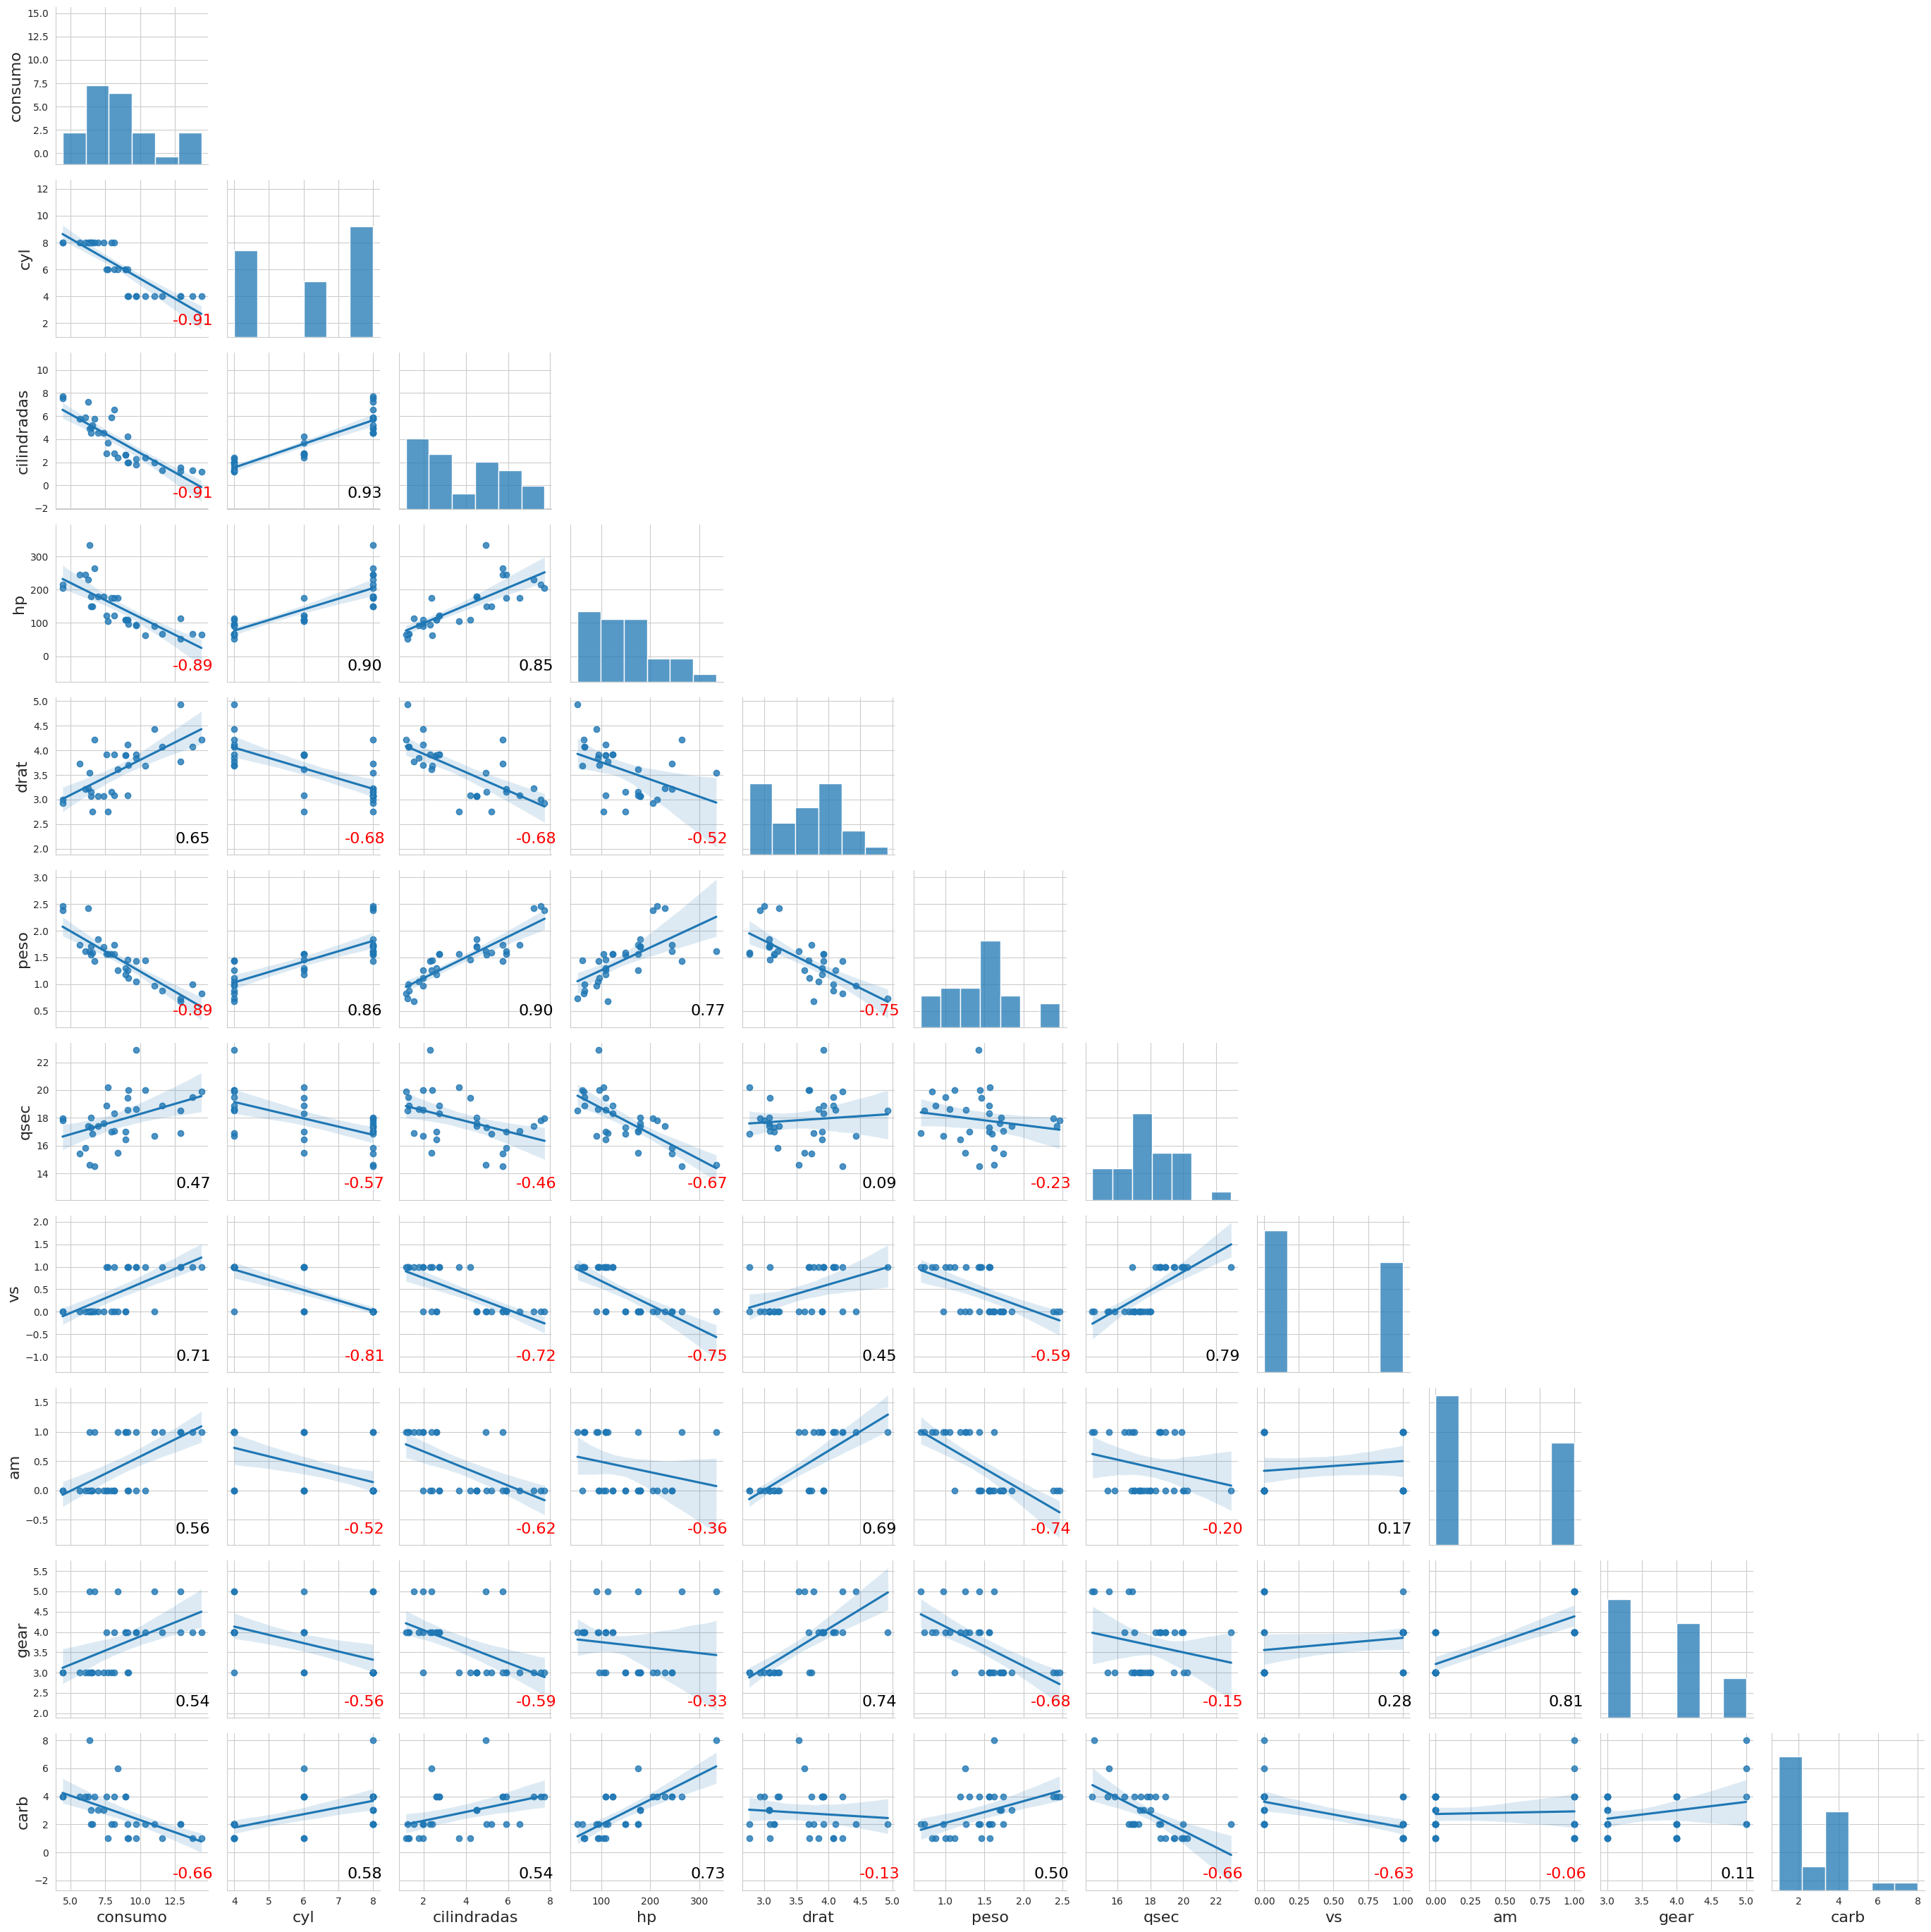

In [ ]:
# como o numero é pequeno e não temos certesa quando a distribuição, vamos usar testes não parametricos
# Calcular a matriz de correlação usando o método de Spearman (não parametrico)
corr = df.corr('spearman')

# Criar o pairplot para variáveis numéricas, este plot é muito utilizado.
g = sns.pairplot(df, kind='reg', diag_kind='hist')

for ax in g.axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)  # Aumentar fonte do eixo X
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

# Adicionar os valores de correlação nos gráficos superiores
for i in range(len(g.axes)):
    for j in range(i+1, len(g.axes)):
    # Esconder os gráficos superiores
      g.axes[i, j].set_visible(False)

    # Calcular a cor baseada na correlação (azul positivo, vermelho negativo)
      color = 'red' if corr.iloc[i, j] < 0 else 'black'

    # Adicionar o valor de correlação
      g.axes[j, i].annotate(f'{corr.iloc[i, j]:.2f}',
                          xy=(0.9, 0.1), xycoords='axes fraction',
                          ha='center', va='center', fontsize=16, color=color)

# Ajustar a plotagem e exibir o gráfico
plt.tight_layout()
plt.show()


Note que permiti que variavies que são categóricas estarem como numéricas, e os valores saíram, e são valores convincentes, porem irreais e podem enganar. Vamos ajustar isso mais a frente.

Agora vamos analisar algumas relações. Algo muito importe é ficar atendo um paradoxo estatístico em que uma tendência em diferentes conjuntos de dados é oposta ou difere à tendência no conjunto de dados agregado. (Paradoxo de Simpsom)

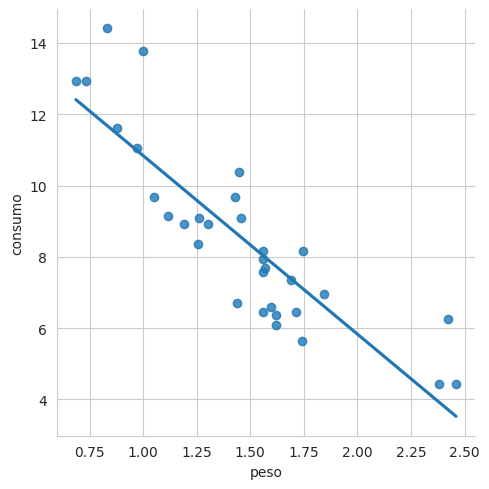

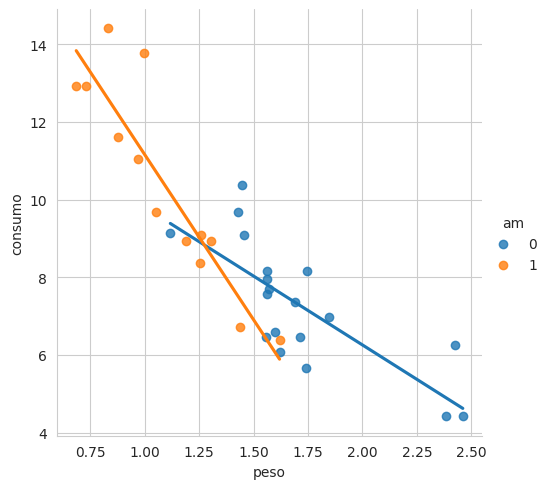

In [ ]:
# vamos plotar o conjunto de dados agregados, ou seja como o peso e o consumo se relacionam mediante uma relação linear
sns.lmplot(x='peso', y='consumo', data=df, ci=None)


# o segundo grafico mostra o grupo separado em relação ao tipo de transmissão.
sns.lmplot(x='peso', y='consumo',hue='am', data=df, ci=None)

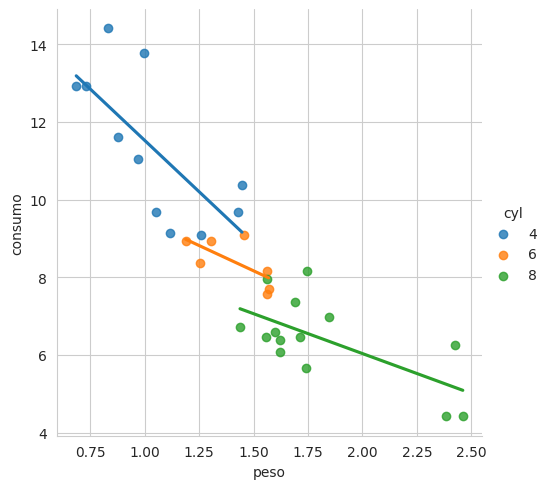

In [ ]:
# podemos ver isso em outras relações ou desagregações.
sns.lmplot(x='peso', y='consumo',hue='cyl', data=df, ci=None)

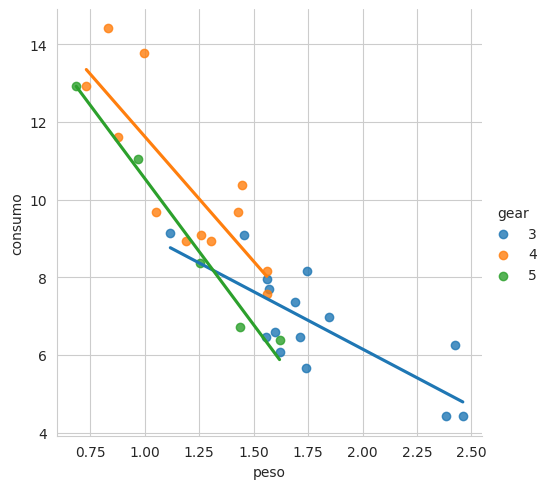

In [ ]:
sns.lmplot(x='peso', y='consumo',hue='gear', data=df, ci=None)

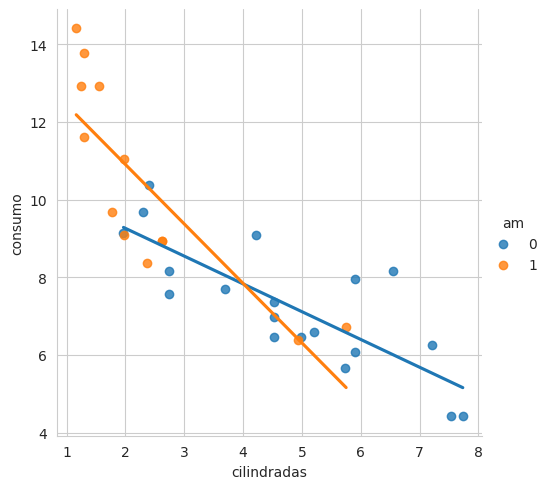

In [ ]:
# vamos ver com relação as cilindradas e o consumo
sns.lmplot(x='cilindradas', y='consumo',hue='am', data=df, ci=None)

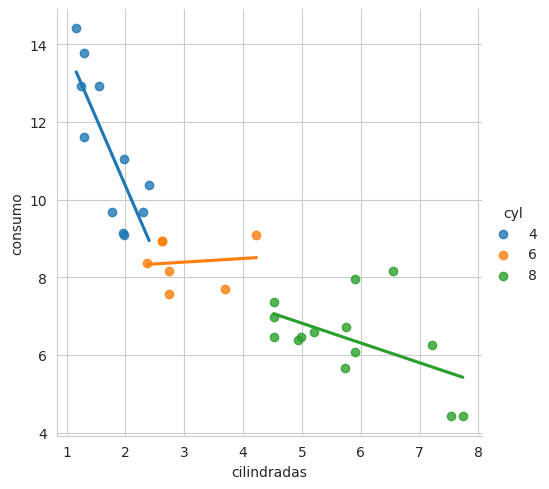

In [ ]:
sns.lmplot(x='cilindradas', y='consumo',hue='cyl', data=df, ci=None)

Alem das correlação que expressam a relação entre varaiveis numéricas, podemos querer saber as relações entre numericas e categoricas e entre categoricas.

Existem inumeros metodos de se fazer encontrar essas relações, para facilitar podemos usar a solução que o pacote `dython`, automatizado os processos de escolhas das metricas.

Metricas utilizadas:

Numerico x numerico: Person ou Spearman

Numerico x categorico: Correlation Ratio

Categorico x categorico: Theil’s U ou crames-V


### Correlation Ratio (η – eta)  
**A medida oficial de associação entre uma variável numérica e uma variável categórica**

#### Fórmula

$$
\boxed{
\eta = \sqrt{
\frac{
\underbrace{\sum_{j=1}^{k} n_j \, (\bar{y}_j - \bar{y})^2}_{\text{Variação Explicada – SSB}}
}{
\underbrace{\sum_{i=1}^{n} (y_i - \bar{y})^2}_{\text{Variação Total – SST}}
}
}}
$$

Ou, de forma mais comum (versão eta-quadrado):

$$
\boxed{
\eta^2 = \frac{SSB}{SST}
\qquad \Rightarrow \qquad
\eta = \sqrt{\eta^2} = \sqrt{\frac{SSB}{SST}}
}
$$


$\eta$ (eta)             → Correlation Ratio                
$\eta^2$                 → eta-quadrado                     
 $k$                      → número de categorias/grupos      
 $n_j$                    → tamanho do grupo j               
 $\bar{y}_j$              → média do grupo j                
 $\bar{y}$                → média geral (total)              
$y_i$                    → valor individual i               
$SSB$ (ou $SS_{\text{between}}$) → Soma de Quadrados Entre grupos   
$SST$ (ou $SS_{\text{total}}$)   → Soma de Quadrados Total          

#

### Cramér’s V –

**A medida oficial de associação entre duas variáveis categóricas**

#### Fórmula oficial (a que cai em toda prova)

$$
\boxed{
V = \sqrt{
\frac{\chi^2}{n \cdot \min(k-1, r-1)}
}}
$$

Onde:
- $V$ → Cramér’s V → sempre entre **0 e 1**
- $\chi^2$ → estatística do teste qui-quadrado de independência
- $n$ → tamanho total da tabela (todas as células somadas)
- $k$ → número de colunas
- $r$ → número de linhas
- $\min(k-1, r-1)$ → menor número de graus de liberdade da tabela


### Theil’s U

**Medida assimétrica de associação entre variáveis categóricas**

$$
\boxed{
U(X|Y) = \frac{H(X) - H(X|Y)}{H(X)}
\qquad \text{ou} \qquad
U(Y|X) = \frac{H(Y) - H(Y|X)}{H(Y)}
}
$$

Onde:
- $U(X|Y)$ → **Theil’s U** → sempre entre **0 e 1**  
  (lê-se: “quanto Y reduz a incerteza sobre X”)
- $H(X)$ → entropia marginal de X (em nats ou bits)  
  (medida total de incerteza/informação de X)
- $H(X|Y)$ → entropia condicional de X dado Y  
  (incerteza que sobra sobre X depois de saber Y)
- $H(Y)$ → entropia marginal de Y
- $H(Y|X)$ → entropia condicional de Y dado X

              consumo       cyl  cilindradas        hp      drat      peso  \
consumo      1.000000 -0.910801    -0.908882 -0.894665  0.651455 -0.886422   
cyl         -0.910801  1.000000     0.927652  0.901791 -0.678881  0.857728   
cilindradas -0.908882  0.927652     1.000000  0.851043 -0.683592  0.897706   
hp          -0.894665  0.901791     0.851043  1.000000 -0.520125  0.774677   
drat         0.651455 -0.678881    -0.683592 -0.520125  1.000000 -0.750390   
peso        -0.886422  0.857728     0.897706  0.774677 -0.750390  1.000000   
qsec         0.466936 -0.572351    -0.459782 -0.666606  0.091869 -0.225401   
vs           0.706597 -0.813789    -0.723664 -0.751593  0.447457 -0.587016   
am           0.562006 -0.522071    -0.624068 -0.362328  0.686571 -0.737713   
gear         0.542782 -0.564310    -0.594470 -0.331402  0.744816 -0.676128   
carb        -0.657498  0.580068     0.539778  0.733379 -0.125223  0.499812   

                 qsec        vs        am      gear      carb  

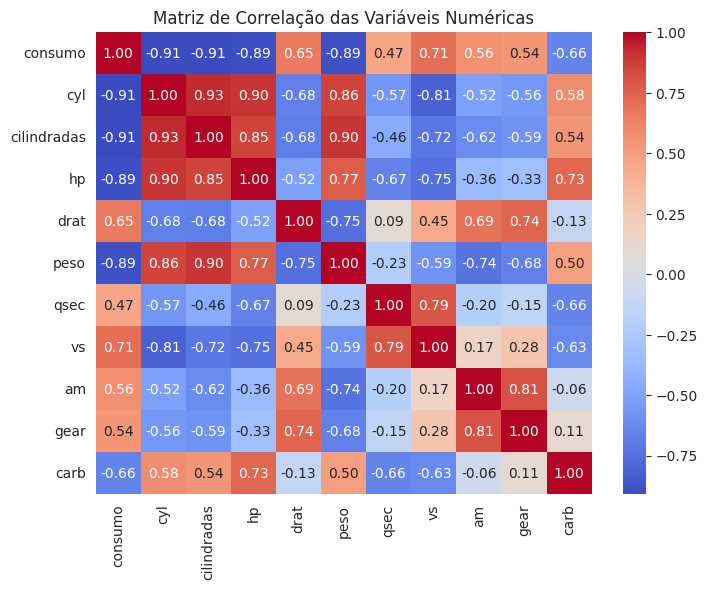

In [ ]:
# dython automatiza a seleção do coeficiente de correlação/associação apropriado com base nos tipos de dados das variáveis que estão sendo comparadas.

#!pip install dython

from dython import nominal

# Calcula a matriz de correlação
correlation_matrix = df.corr("spearman")

# Mostra a matriz de correlação
print(correlation_matrix)

# Opcional: Visualizar a matriz de correlação com um heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

In [ ]:
# vamos passar as numericas para categoricas, apenas aquelas com valor unicos inferiores a 4
for column in df.columns:
  if pd.api.types.is_numeric_dtype(df[column]) and df[column].nunique() < 7:
    df[column] = df[column].astype('category')

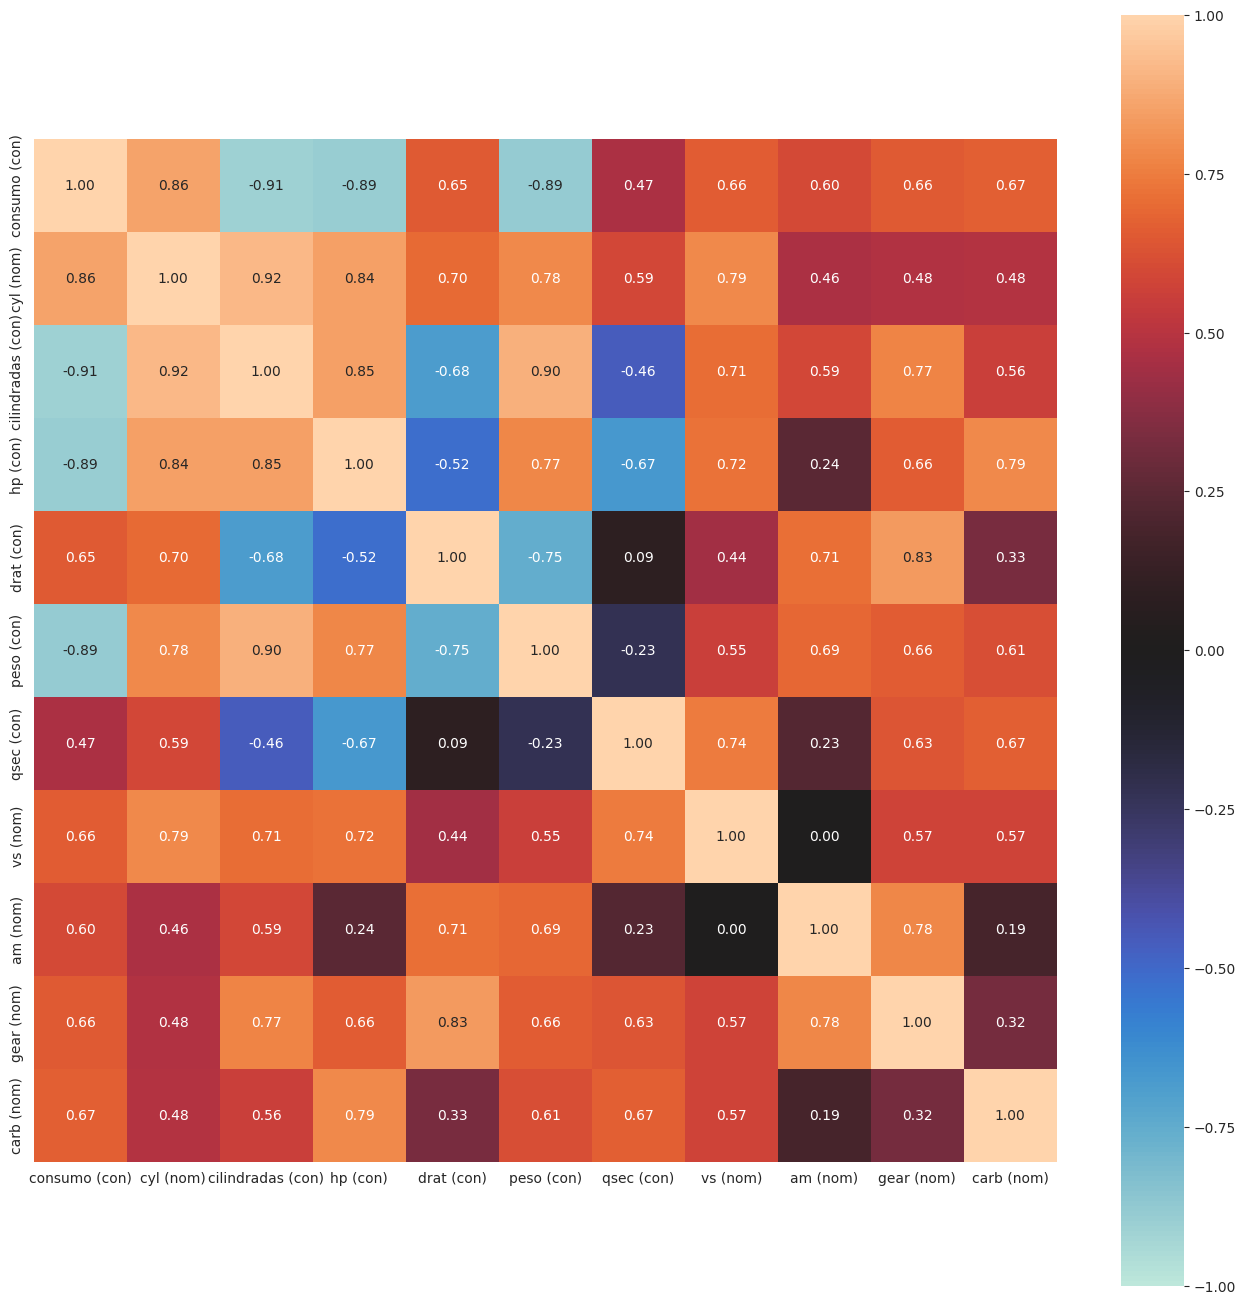

{'corr':                    consumo (con)  cyl (nom)  cilindradas (con)  hp (con)  \
consumo (con)           1.000000   0.855839          -0.908882 -0.894665   
cyl (nom)               0.855839   1.000000           0.915249  0.844910   
cilindradas (con)      -0.908882   0.915249           1.000000  0.851043   
hp (con)               -0.894665   0.844910           0.851043  1.000000   
drat (con)              0.651455   0.701757          -0.683592 -0.520125   
peso (con)             -0.886422   0.782571           0.897706  0.774677   
qsec (con)              0.466936   0.591266          -0.459782 -0.666606   
vs (nom)                0.664039   0.788946           0.710416  0.723097   
am (nom)                0.599832   0.464313           0.591227  0.243204   
gear (nom)              0.655095   0.481963           0.767118  0.663806   
carb (nom)              0.666730   0.484710           0.560476  0.787264   

                   drat (con)  peso (con)  qsec (con)  vs (nom)  am (nom)  \
c

In [ ]:
# Calcula a matriz de correlação
correlation_matrix = nominal.associations(df, mark_columns=True, num_num_assoc='spearman')

# Mostra a matriz de correlação
print(correlation_matrix)



### Mutual Information (Informação Mútua)

É, hoje em dia, **a métrica poderosa e moderna** para medir associação entre **qualquer par de variáveis** (numérica × numérica, numérica × categórica, categórica × categórica).

#### Definição simples e intuitiva
**Mutual Information (I(X;Y))** mede **quantos bits de incerteza sobre uma variável são reduzidos quando sabemos o valor da outra**.

- I(X;Y) = 0  → as duas variáveis são **independentes**  
- I(X;Y) > 0  → saber uma **reduz a incerteza** sobre a outra  
- Valor máximo teórico = entropia da variável menos entropizada

#### Fórmula



$$
\boxed{
I(X;Y) = H(X) + H(Y) - H(X,Y)
}
$$

$$
\boxed{
H(X) = -\sum_{i=1}^{n} p(x_i) \log_2 p(x_i)
}
$$

Onde H = entropia de Shannon.



Ela captura **qualquer tipo de relação** (linear, quadrática, sinusoidal, em escada, etc.) desde que seja determinística ou estatisticamente dependente.

#### Interpretação prática dos valores

| Valor da MI (em nats) | Interpretação prática                                 |
|-----------------------|-------------------------------------------------------|
| 0.00 – 0.10           | Associação nula ou muito fraca                        |
| 0.10 – 0.30           | Associação fraca                                      |
| 0.30 – 0.70           | Associação moderada                                   |
| 0.70 – 1.50           | Associação forte                                      |
| > 1.50                | Associação muito forte (quase determinística)         |



In [ ]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
import numpy as np

# Gerar dados com diferentes tipos de relações
np.random.seed(42)
x = np.linspace(-1, 1, 200)
noise = np.random.uniform(-0.1, 0.1, x.shape[0])

y_linear = x + noise
y_quad = x**2 + noise
y_sine = np.sin(x * np.pi) + noise
# 1. Relação Linear


mi_linear = mutual_info_regression(x.reshape(-1, 1), y_linear)[0]
pearson_linear = np.corrcoef(x, y_linear,"spearman")[0, 1]

# 2. Relação Quadrática (não-linear)

mi_quad = mutual_info_regression(x.reshape(-1, 1), y_quad)[0]
pearson_quad = np.corrcoef(x, y_quad)[0, 1]

# 3. Relação Senoidal (periódica)


mi_sine = mutual_info_regression(x.reshape(-1, 1), y_sine)[0]
pearson_sine = np.corrcoef(x, y_sine)[0, 1]

# Exibir resultados
results = {
    "Relação Linear": [pearson_linear, mi_linear],
    "Relação Quadrática": [pearson_quad, mi_quad],
    "Relação Senoidal": [pearson_sine, mi_sine]
}

results_df = pd.DataFrame(results, index=['Pearson', 'Mutual Info (MI)']).T.round(3)
print(results_df)

                    Pearson  Mutual Info (MI)
Relação Linear        0.995             2.151
Relação Quadrática    0.012             1.440
Relação Senoidal      0.776             2.003


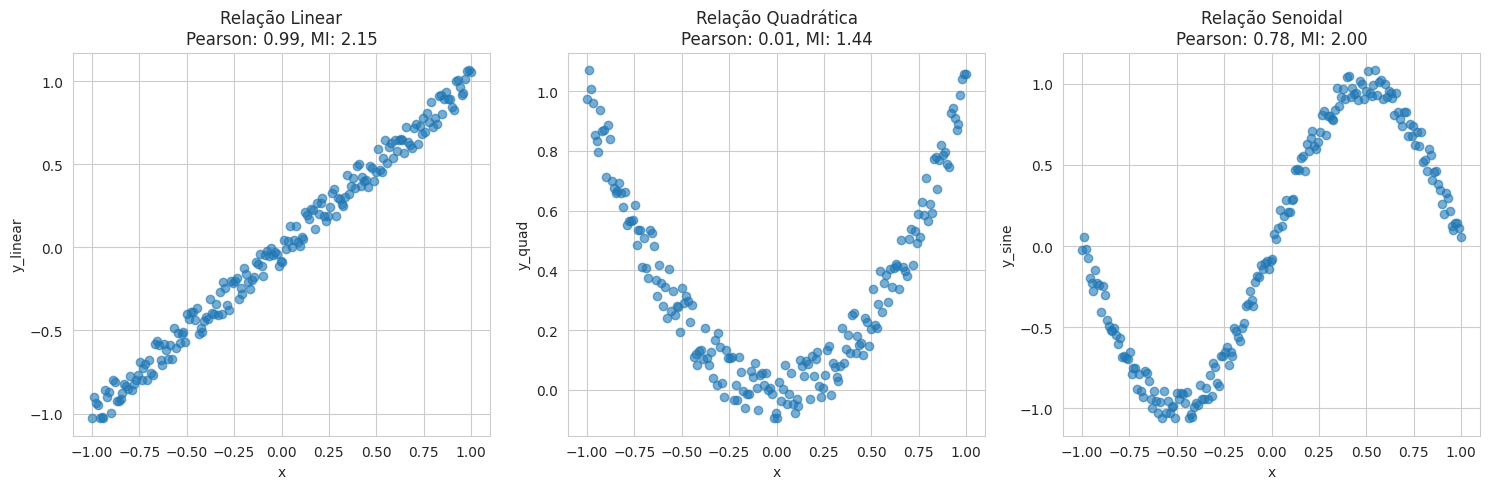

In [ ]:
# Plotar as relações e os valores de correlação
plt.figure(figsize=(15, 5))

# Relação Linear
plt.subplot(1, 3, 1)
plt.scatter(x, y_linear, alpha=0.6)
plt.title(f'Relação Linear\nPearson: {pearson_linear:.2f}, MI: {mi_linear:.2f}')
plt.xlabel('x')
plt.ylabel('y_linear')

# Relação Quadrática
plt.subplot(1, 3, 2)
plt.scatter(x, y_quad, alpha=0.6)
plt.title(f'Relação Quadrática\nPearson: {pearson_quad:.2f}, MI: {mi_quad:.2f}')
plt.xlabel('x')
plt.ylabel('y_quad')

# Relação Senoidal
plt.subplot(1, 3, 3)
plt.scatter(x, y_sine, alpha=0.6)
plt.title(f'Relação Senoidal\nPearson: {pearson_sine:.2f}, MI: {mi_sine:.2f}')
plt.xlabel('x')
plt.ylabel('y_sine')

plt.tight_layout()
plt.show()

In [ ]:
# mutual information

from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Separar features (X) e alvo (y)
X = df.drop('am', axis=1)
y = df['am']

# Instanciar e configurar o seletor
# Queremos selecionar as 3 melhores features (k=3).
# O critério de seleção (score_func) será a Informação Mútua.
k_best_selector = SelectKBest(score_func=mutual_info_classif, k=3) #mutual_info_regression

# "Treinar" o seletor nos dados completos
# O método .fit() calcula o score para cada feature em X em relação a y.
k_best_selector.fit(X, y)
k_best_selector.scores_
# Obter os resultados
# O atributo .scores_ contém a pontuação de TODAS as features.
all_feature_scores = pd.Series(k_best_selector.scores_, index=X.columns).sort_values(ascending=False)

# Para obter apenas os nomes das k features selecionadas, usamos .get_support()
# que retorna uma máscara booleana [True, False, True, ...]
selected_features_mask = k_best_selector.get_support()
selected_features_names = X.columns[selected_features_mask]

# 5. Exibir os resultados da análise
print("--- Análise de Seleção de Features com SelectKBest ---")

print("\nScores de Informação Mútua para todas as features:")
print(all_feature_scores)

print("\n---------------------------------------------------------")
print(f"As {len(selected_features_names)} melhores features selecionadas (k=3) foram:")
print(list(selected_features_names))



--- Análise de Seleção de Features com SelectKBest ---

Scores de Informação Mútua para todas as features:
peso           0.441992
gear           0.427655
drat           0.316556
cilindradas    0.216703
consumo        0.202709
qsec           0.150671
vs             0.095649
hp             0.086660
cyl            0.085063
carb           0.000000
dtype: float64

---------------------------------------------------------
As 3 melhores features selecionadas (k=3) foram:
['drat', 'peso', 'gear']


In [ ]:

import statsmodels.formula.api as sm
import itertools # Import the itertools module

# Lista para armazenar os resultados de cada modelo
model_results = []

# Lista de todas as variáveis independentes
independent_variables = df.columns.drop('consumo')

# Loop para gerar todos os modelos possíveis
for i in range(1, len(independent_variables) + 1):
  for combination in itertools.combinations(independent_variables, i):
    formula = 'consumo ~ ' + ' + '.join(combination)
    model = sm.ols(formula, data=df).fit()
    model_results.append((formula, model.aic))

# Encontrar o modelo com o menor AIC
best_model_formula, min_aic = min(model_results, key=lambda x: x[1])
print(f"Melhor modelo: {best_model_formula}")
print(f"AIC: {min_aic}")

# Ajustar o modelo com a melhor combinação de variáveis
best_model = sm.ols(best_model_formula, data=df).fit()

# Imprimir os resultados do modelo
print(best_model.summary())

Melhor modelo: consumo ~ peso + qsec + am
AIC: 97.35673982520709
                            OLS Regression Results                            
Dep. Variable:                consumo   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     52.75
Date:                Wed, 03 Sep 2025   Prob (F-statistic):           1.21e-11
Time:                        21:24:00   Log-Likelihood:                -44.678
No. Observations:                  32   AIC:                             97.36
Df Residuals:                      28   BIC:                             103.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [ ]:
#

# Verificar a multicolinearidade usando o VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Criar uma matriz com as variáveis independentes do modelo
X = df[['peso', 'qsec', 'am']]


# Calcular o VIF para cada variável
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

# Interpretação:
# Um VIF acima de  10 indica uma possível multicolinearidade.

  feature        VIF
0    peso  13.488703
1    qsec  17.217505
2      am   2.186566


In [ ]:
sm.ols('consumo ~ peso  + qsec + am', data=df).fit().summary()

In [ ]:


from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Selecionar as features (cilindradas e consumo) e o target (cyl)
X = df[['cilindradas', 'consumo']]
y = df['cyl']

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar o modelo KNN
knn = KNeighborsClassifier(n_neighbors=3)  # Escolha o número de vizinhos (k)

# Treinar o modelo
knn.fit(X_train, y_train)

# Fazer previsões com os dados de teste
y_pred = knn.predict(X_test)

# Avaliar a precisão do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo KNN: {accuracy}")

# Plotar os dados e as fronteiras de decisão (opcional)
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Criar um mapa de cores
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Criar uma grade de pontos para plotar as fronteiras de decisão
h = .02  # Tamanho da grade
x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Fazer previsões para cada ponto da grade
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

# Plotar as fronteiras de decisão
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plotar os pontos de dados
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
plt.xlabel('Cilindradas')
plt.ylabel('Consumo')
plt.title('Classificação KNN - Número de Cilindros')
plt.show()